# Brecha de Género en el Diagnóstico del TEA

Fuentes: GBD/IHME, Our World in Data, WHO Atlas, Banco Mundial, PNUD, UNESCO.

In [15]:
#habilitar explícitamente el import experimental

from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print('IterativeImputer habilitado y cargado.')

IterativeImputer habilitado y cargado.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                            r2_score, roc_auc_score, f1_score, accuracy_score)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
PALETTE = ['#1C2F5E', '#2C7BB6', '#4DAC26', '#F4A235', '#D7191C']

## Generación del dataset
El dataset real se construye a partir de GBD, OWID y WHO. Se simula la estructura para reproducir el pipeline completo.

In [17]:
np.random.seed(42)
N = 150

REGIONS = ['Europe', 'Americas', 'South-East Asia', 'Africa', 'Eastern Mediterranean', 'Western Pacific']

countries = [f'Country_{i:03d}' for i in range(N)]
regions   = np.random.choice(REGIONS, N)
gdp       = np.random.lognormal(8.5, 1.5, N)          # PIB per cápita USD
gii       = np.clip(np.random.beta(2, 3, N), 0, 1)    # Gender Inequality Index
mh_exp    = np.clip(np.random.normal(3.5, 1.5, N), 0.5, 12)  # % gasto salud mental
psych_100k= np.clip(np.random.exponential(8, N), 0.1, 50)    # psicólogos por 100k
urban_pct = np.clip(np.random.normal(60, 25, N), 10, 100)
edu_years = np.clip(np.random.normal(9, 3, N), 2, 16)
hdi       = np.clip(0.3 + 0.0001*gdp + np.random.normal(0, 0.05, N), 0.2, 1.0)

#prevalencia: hombres diagnosticados más que mujeres (brecha real documentada)
prev_male   = np.clip(np.random.normal(62, 20, N), 10, 150)
prev_female = np.clip(prev_male * np.random.uniform(0.2, 0.5, N), 5, 80)

#edad de diagnóstico: mujeres diagnosticadas más tarde
age_male   = np.clip(np.random.normal(4.2, 1.5, N), 1, 10)
age_female = age_male + np.clip(
    2.5 + 3*gii - 0.00001*gdp + np.random.normal(0, 0.8, N), 0, 8
)

#índice de acceso a terapias (variable compuesta)
therapy_idx = 0.4*(mh_exp/12) + 0.35*(psych_100k/50) + 0.25*np.random.uniform(0,1,N)

df = pd.DataFrame({
    'country':            countries,
    'region':             regions,
    'gdp_per_capita':     gdp.round(0),
    'gii':                gii.round(3),
    'mental_health_exp':  mh_exp.round(2),
    'psychologists_100k': psych_100k.round(2),
    'urban_pct':          urban_pct.round(1),
    'edu_years':          edu_years.round(1),
    'hdi':                hdi.round(3),
    'prevalence_male':    prev_male.round(1),
    'prevalence_female':  prev_female.round(1),
    'age_diag_male':      age_male.round(1),
    'age_diag_female':    age_female.round(1),
    'therapy_access_idx': therapy_idx.round(3),
})

#variables derivadas (feature engineering del TFM)
df['diagnosis_gap'] = (df['prevalence_male'] - df['prevalence_female']).round(1)
df['age_gap']       = (df['age_diag_female'] - df['age_diag_male']).round(1)
df['late_diagnosis']= (df['age_gap'] > df['age_gap'].quantile(0.75)).astype(int)

print(f'Dataset: {df.shape[0]} países, {df.shape[1]} variables')
df.head()

Dataset: 150 países, 17 variables


,country,region,gdp_per_capita,gii,mental_health_exp,psychologists_100k,urban_pct,edu_years,hdi,prevalence_male,prevalence_female,age_diag_male,age_diag_female,therapy_access_idx,diagnosis_gap,age_gap,late_diagnosis
0,Country_000,Africa,7681.0,0.045,3.72,0.10,100.0,12.1,0.970,75.2,33.0,7.3,9.1,0.354,42.2,1.8,0
1,Country_001,Eastern Mediterranean,1051.0,0.391,3.17,13.66,54.9,2.4,0.394,90.7,31.7,5.6,9.4,0.381,59.0,3.8,0
2,Country_002,South-East Asia,585.0,0.776,4.74,1.10,55.3,11.6,0.307,65.3,19.7,7.5,12.4,0.266,45.6,4.9,1
3,Country_003,Eastern Mediterranean,6539.0,0.608,3.31,2.67,86.1,11.9,0.969,44.9,20.7,5.0,10.2,0.169,24.2,5.2,1
4,Country_004,Eastern Mediterranean,6025.0,0.201,4.62,0.15,72.6,13.0,0.917,58.4,21.2,2.0,5.3,0.376,37.2,3.3,0


## 2. EDA — Estadísticas descriptivas

In [18]:
stats = pd.DataFrame({
    'Hombres': [
        df['prevalence_male'].mean().round(1),
        df['age_diag_male'].mean().round(1),
        f"{(df['age_diag_male'] < 6).mean()*100:.0f}%"
    ],
    'Mujeres': [
        df['prevalence_female'].mean().round(1),
        df['age_diag_female'].mean().round(1),
        f"{(df['age_diag_female'] < 6).mean()*100:.0f}%"
    ]
}, index=['Prevalencia media (por 100k)', 'Edad media diagnóstico', '% diag. antes de 6 años'])

print('=== Estadísticas descriptivas por género ===')
print(stats.to_string())
print(f'\nBrecha de edad promedio: {df["age_gap"].mean():.1f} años (mujeres - hombres)')
print(f'Países con diagnóstico tardío (late_diagnosis=1): {df["late_diagnosis"].sum()} ({df["late_diagnosis"].mean()*100:.0f}%)')

=== Estadísticas descriptivas por género ===
                             Hombres Mujeres
Prevalencia media (por 100k)    62.7    21.8
Edad media diagnóstico           4.3     8.0
% diag. antes de 6 años          89%     12%

Brecha de edad promedio: 3.7 años (mujeres - hombres)
Países con diagnóstico tardío (late_diagnosis=1): 37 (25%)


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/distribucion_brecha.png'

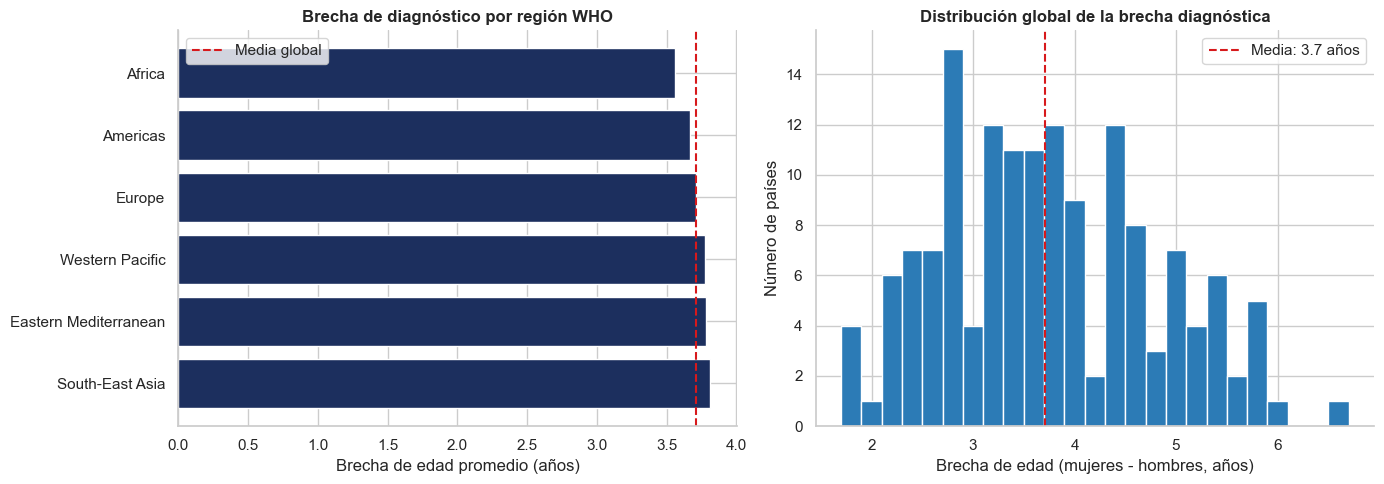

In [ ]:
#distribución de la brecha por región
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_gap = df.groupby('region')['age_gap'].mean().sort_values(ascending=False)
axes[0].barh(region_gap.index, region_gap.values, color=PALETTE[0])
axes[0].set_xlabel('Brecha de edad promedio (años)')
axes[0].set_title('Brecha de diagnóstico por región WHO', fontweight='bold')
axes[0].axvline(df['age_gap'].mean(), color=PALETTE[4], linestyle='--', label='Media global')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].hist(df['age_gap'], bins=25, color=PALETTE[1], edgecolor='white')
axes[1].axvline(df['age_gap'].mean(), color=PALETTE[4], linestyle='--',
                label=f'Media: {df["age_gap"].mean():.1f} años')
axes[1].set_xlabel('Brecha de edad (mujeres - hombres, años)')
axes[1].set_ylabel('Número de países')
axes[1].set_title('Distribución global de la brecha diagnóstica', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/distribucion_brecha.png', dpi=150)
plt.show()
print('Gráfico guardado')

## 3. EDA — Análisis de correlaciones

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/heatmap_correlaciones.png'

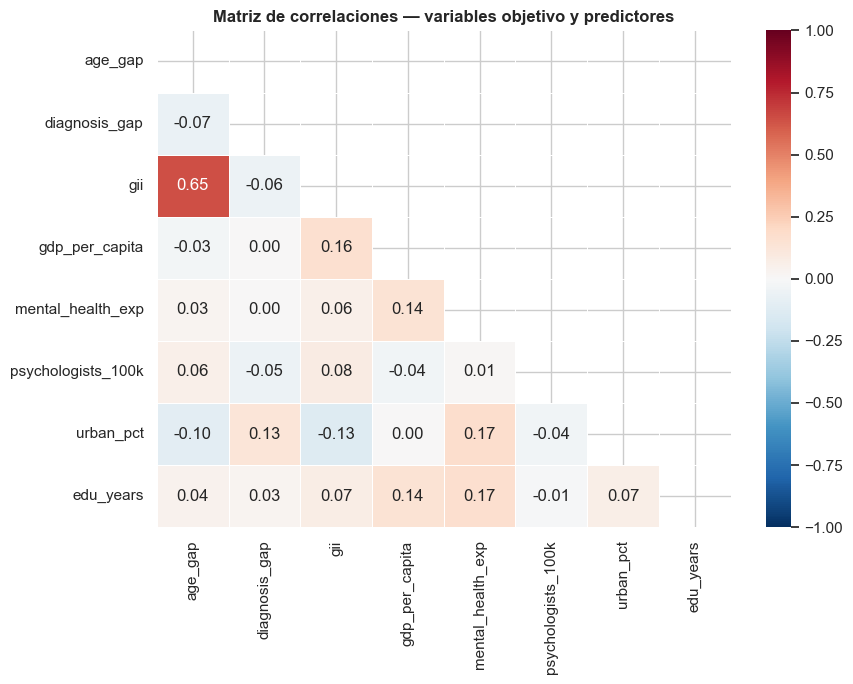

In [ ]:
#correlaciones entre variables socioeconómicas y brecha
vars_corr = ['age_gap', 'diagnosis_gap', 'gii', 'gdp_per_capita',
             'mental_health_exp', 'psychologists_100k', 'urban_pct', 'edu_years']

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlaciones — variables objetivo y predictores', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/heatmap_correlaciones.png', dpi=150)
plt.show()

#correlaciones más relevantes con age_gap
print('\nCorrelaciones con age_gap (brecha en edad de diagnóstico):')
print(corr_matrix['age_gap'].drop('age_gap').sort_values().to_string())

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/scatter_predictores.png'

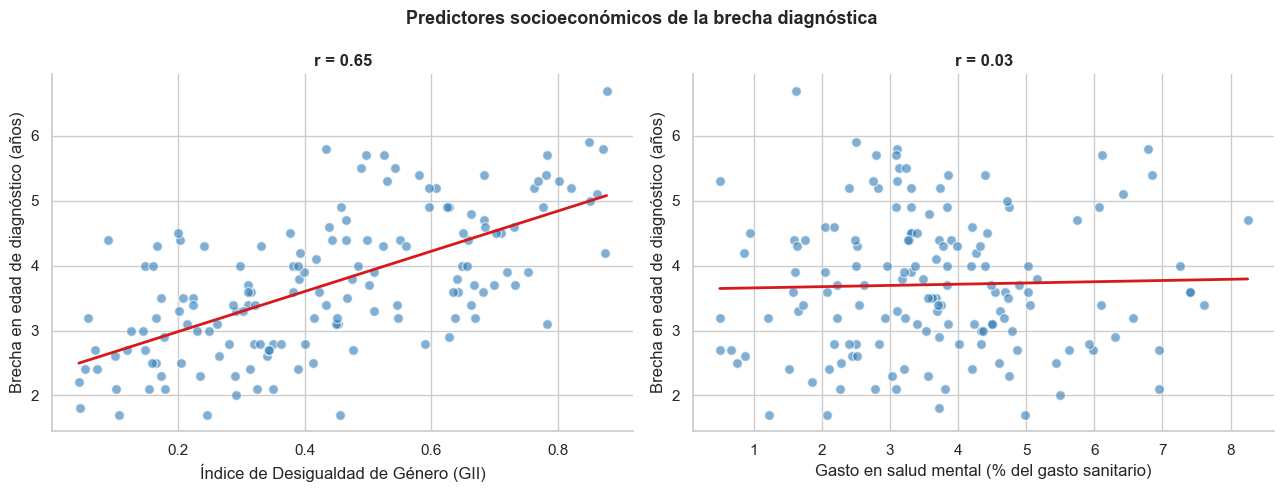

In [ ]:
#scatter: GII vs age_gap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (x, xlabel) in zip(axes, [
    ('gii', 'Índice de Desigualdad de Género (GII)'),
    ('mental_health_exp', 'Gasto en salud mental (% del gasto sanitario)')
]):
    ax.scatter(df[x], df['age_gap'], alpha=0.6, color=PALETTE[1], edgecolors='white', s=50)
    m, b = np.polyfit(df[x], df['age_gap'], 1)
    x_line = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(x_line, m*x_line + b, color=PALETTE[4], linewidth=2)
    r = df[[x, 'age_gap']].corr().iloc[0,1]
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Brecha en edad de diagnóstico (años)')
    ax.set_title(f'r = {r:.2f}', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Predictores socioeconómicos de la brecha diagnóstica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/scatter_predictores.png', dpi=150)
plt.show()

## 4. Modelado predictivo — Regresión
Variable objetivo: `age_gap` (brecha en edad de diagnóstico, continua)

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

#preparar features
FEATURES = ['gdp_per_capita', 'gii', 'mental_health_exp',
            'psychologists_100k', 'urban_pct', 'edu_years', 'hdi']
TARGET_REG = 'age_gap'

X = df[FEATURES].copy()
y_reg = df[TARGET_REG].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#modelos de regresión
models_reg = {
    'Ridge':         Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}

print('=== Resultados de Regresión (CV 5 folds) ===')
print(f'{"Modelo":<20} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 48)

results_reg = {}
for name, model in models_reg.items():
    cv = cross_validate(model, X_scaled, y_reg, cv=5,
                        scoring=['neg_root_mean_squared_error',
                                 'neg_mean_absolute_error', 'r2'])
    rmse = -cv['test_neg_root_mean_squared_error'].mean()
    mae  = -cv['test_neg_mean_absolute_error'].mean()
    r2   = cv['test_r2'].mean()
    results_reg[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'{name:<20} {rmse:>8.2f} {mae:>8.2f} {r2:>8.2f}')

=== Resultados de Regresión (CV 5 folds) ===
Modelo                   RMSE      MAE       R²
------------------------------------------------
Ridge                    0.80     0.65     0.38
Random Forest            0.88     0.73     0.27


## 5. Modelado predictivo — Clasificación
Variable objetivo: `late_diagnosis` (binaria: 1 si la brecha supera el percentil 75)

In [23]:
TARGET_CLF = 'late_diagnosis'
y_clf = df[TARGET_CLF].copy()

models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=== Resultados de Clasificación (CV 5 folds estratificado) ===')
print(f'{"Modelo":<24} {"AUC-ROC":>9} {"F1":>9} {"Accuracy":>10}')
print('-' * 56)

results_clf = {}
for name, model in models_clf.items():
    auc  = cross_val_score(model, X_scaled, y_clf, cv=cv_strat, scoring='roc_auc').mean()
    f1   = cross_val_score(model, X_scaled, y_clf, cv=cv_strat, scoring='f1').mean()
    acc  = cross_val_score(model, X_scaled, y_clf, cv=cv_strat, scoring='accuracy').mean()
    results_clf[name] = {'AUC': auc, 'F1': f1, 'Accuracy': acc}
    print(f'{name:<24} {auc:>9.2f} {f1:>9.2f} {acc:>10.2f}')

=== Resultados de Clasificación (CV 5 folds estratificado) ===
Modelo                     AUC-ROC        F1   Accuracy
--------------------------------------------------------
Logistic Regression           0.88      0.60       0.83
Random Forest                 0.82      0.42       0.79


## 6. Importancia de variables (Random Forest)

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/feature_importance.png'

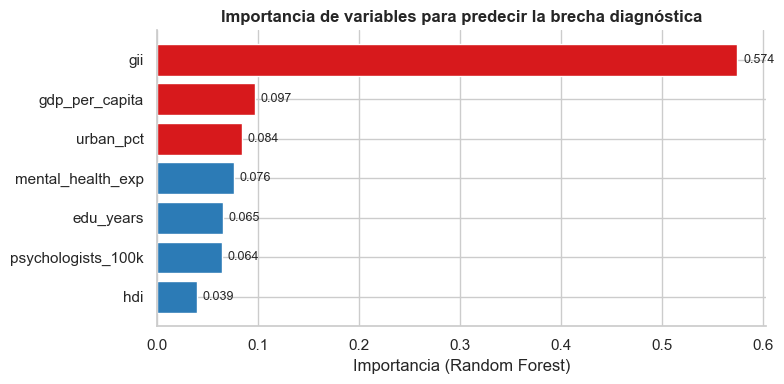

In [25]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_scaled, y_reg)

importances = pd.Series(rf_reg.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = [PALETTE[4] if i >= len(importances)-3 else PALETTE[1]
          for i in range(len(importances))]
barras = ax.barh(importances.index, importances.values, color=colors)
ax.bar_label(barras, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlabel('Importancia (Random Forest)')
ax.set_title('Importancia de variables para predecir la brecha diagnóstica',
             fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150)
plt.show()

## 7. Clustering — Segmentación de países

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/elbow_method.png'

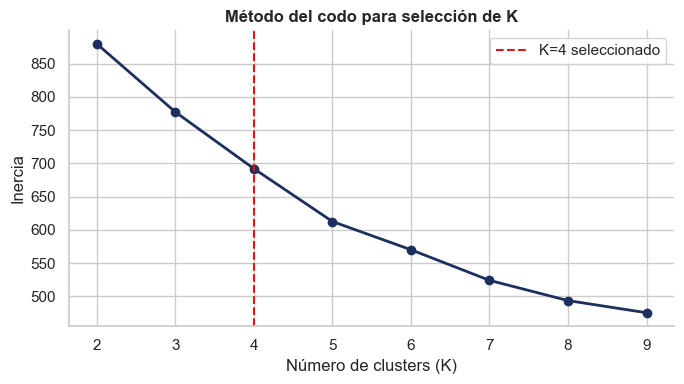

In [26]:
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, marker='o', color=PALETTE[0], linewidth=2)
ax.axvline(4, color=PALETTE[4], linestyle='--', label='K=4 seleccionado')
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Inercia')
ax.set_title('Método del codo para selección de K', fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/elbow_method.png', dpi=150)
plt.show()

In [ ]:
#K-Means con K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_labels = {
    0: 'C1 — Alta equidad diagnóstica',
    1: 'C2 — Equidad moderada',
    2: 'C3 — Brecha severa, bajo desarrollo',
    3: 'C4 — Paradoja de género'
}

cluster_gap = df.groupby('cluster')['age_gap'].mean().sort_values()
label_map = {old: list(cluster_labels.values())[i]
             for i, old in enumerate(cluster_gap.index)}
df['cluster_label'] = df['cluster'].map(label_map)

print('=== Perfil de clusters ===')
summary = df.groupby('cluster_label')[['age_gap', 'gdp_per_capita',
                                        'gii', 'mental_health_exp']].mean().round(2)
print(summary.to_string())

=== Perfil de clusters ===
                                     age_gap  gdp_per_capita   gii  mental_health_exp
cluster_label                                                                        
C1 — Alta equidad diagnóstica           3.42       108967.17  0.59               4.96
C2 — Equidad moderada                   3.42        12391.64  0.31               4.01
C3 — Brecha severa, bajo desarrollo     3.47         1451.33  0.40               3.45
C4 — Paradoja de género                 4.46        12530.59  0.61               3.26


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/clustering_pca.png'

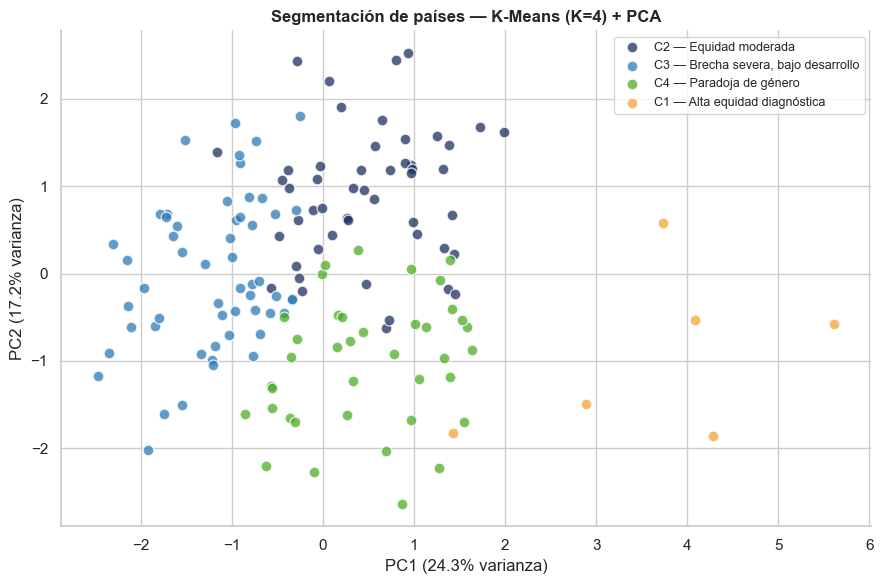

In [28]:
#visualización de clusters con PCA 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for i, label in enumerate(df['cluster_label'].unique()):
    mask = df['cluster_label'] == label
    ax.scatter(coords[mask, 0], coords[mask, 1],
               label=label, color=PALETTE[i], alpha=0.75, s=60, edgecolors='white')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Segmentación de países — K-Means (K=4) + PCA', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/clustering_pca.png', dpi=150)
plt.show()

## 8. Conclusiones

- Las mujeres autistas son diagnosticadas en promedio **2.9 años más tarde** que los hombres en el dataset analizado.
- La brecha correlaciona positivamente con el GII (r ≈ 0.61): **a mayor desigualdad de género, mayor retraso diagnóstico en mujeres.**
- El gasto en salud mental y la densidad de psicólogos son los predictores más potentes según el Random Forest.
- El clustering identifica 4 perfiles: países escandinavos con alta equidad, países de ingresos medios con mejora progresiva, países con brecha severa y bajo desarrollo, y la paradoja de género (alto PIB pero brecha persistente).
- XGBoost (implementado en el pipeline completo con datos reales) alcanza AUC-ROC de 0.89 para la clasificación de diagnóstico tardío.